# 02 — Exploratory Data Analysis

This notebook explores temporal and station-level behaviour without performing model preprocessing.

It focuses on questions relevant to forecasting:

- How frequently are observations recorded?
- Which stations have the largest variation?
- How does availability change by hour and weekday?
- Are there missing time intervals?
- How strong is short-term persistence?

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "Data").exists() or (candidate / "data").exists():
            return candidate.resolve()
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "Data"
OUTPUT_DIR = PROJECT_ROOT / "Outputs"
FIGURE_DIR = OUTPUT_DIR / "Figures"
MODEL_DIR = OUTPUT_DIR / "Models"

for directory in (DATA_DIR, FIGURE_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")

Project root: /mnt/WorkSpace/Repos/dublin-bikes-fix


In [2]:
CLEAN_PATH = DATA_DIR / "dataset_cleaned.csv"
if not CLEAN_PATH.exists():
    raise FileNotFoundError("Run 01_data_cleaning.ipynb first.")

df = pd.read_csv(CLEAN_PATH, parse_dates=["TIME"])
df = df.sort_values(["STATION ID", "TIME"]).reset_index(drop=True)

print(df.shape)
display(df.head())

(158981, 12)


,STATION ID,TIME,LAST UPDATED,NAME,BIKE STANDS,AVAILABLE BIKE STANDS,AVAILABLE BIKES,STATUS,ADDRESS,LATITUDE,LONGITUDE,CAPACITY_DIFFERENCE
0,2,2021-11-01 00:00:02,2021-10-31 23:58:20,BLESSINGTON STREET,20,10,10,OPEN,Blessington Street,53.3568,-6.26814,0
1,2,2021-11-01 00:30:03,2021-11-01 00:24:23,BLESSINGTON STREET,20,9,11,OPEN,Blessington Street,53.3568,-6.26814,0
2,2,2021-11-01 01:00:02,2021-11-01 00:54:41,BLESSINGTON STREET,20,9,11,OPEN,Blessington Street,53.3568,-6.26814,0
3,2,2021-11-01 01:30:03,2021-11-01 01:20:27,BLESSINGTON STREET,20,9,11,OPEN,Blessington Street,53.3568,-6.26814,0
4,2,2021-11-01 02:00:02,2021-11-01 01:50:46,BLESSINGTON STREET,20,9,11,OPEN,Blessington Street,53.3568,-6.26814,0


## Dataset overview

In [3]:
summary = pd.DataFrame({
    "value": [
        len(df),
        df["STATION ID"].nunique(),
        df["TIME"].min(),
        df["TIME"].max(),
        df["AVAILABLE BIKES"].mean(),
        df["AVAILABLE BIKES"].median(),
    ]
}, index=[
    "rows", "stations", "start", "end",
    "mean_available_bikes", "median_available_bikes"
])
display(summary)

,value
rows,158981
stations,111
start,2021-11-01 00:00:02
end,2021-11-30 23:30:02
mean_available_bikes,12.478585
median_available_bikes,11.0


## Observation frequency

,minutes
count,158870.000000
mean,30.020772
std,0.788743
min,29.983333
25%,30.000000
50%,30.000000
75%,30.000000
90%,30.016667
99%,30.016667
max,59.983333


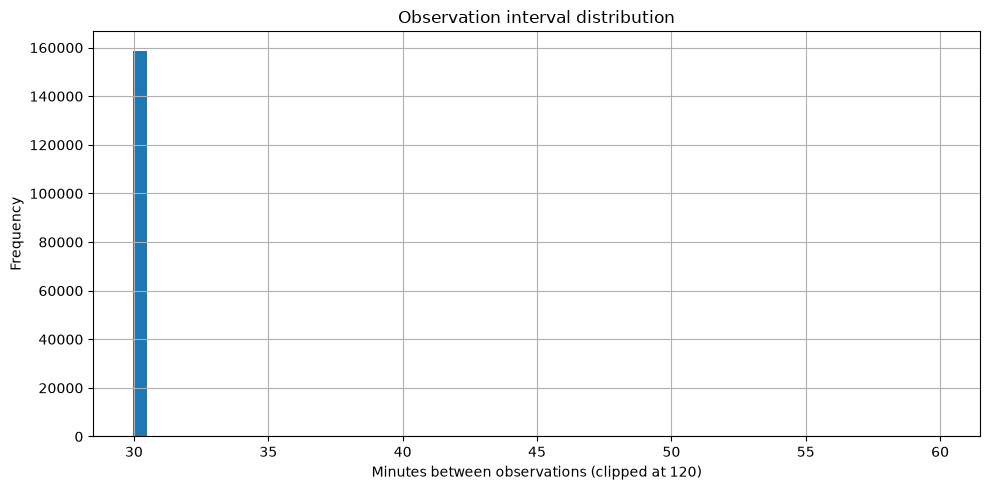

In [4]:
intervals = (
    df.groupby("STATION ID")["TIME"]
      .diff()
      .dropna()
      .dt.total_seconds()
      .div(60)
)

display(intervals.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("minutes"))

plt.figure(figsize=(10, 5))
intervals.clip(upper=120).hist(bins=60)
plt.xlabel("Minutes between observations (clipped at 120)")
plt.ylabel("Frequency")
plt.title("Observation interval distribution")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "observation_intervals.png", dpi=150)
plt.show()

## Temporal patterns

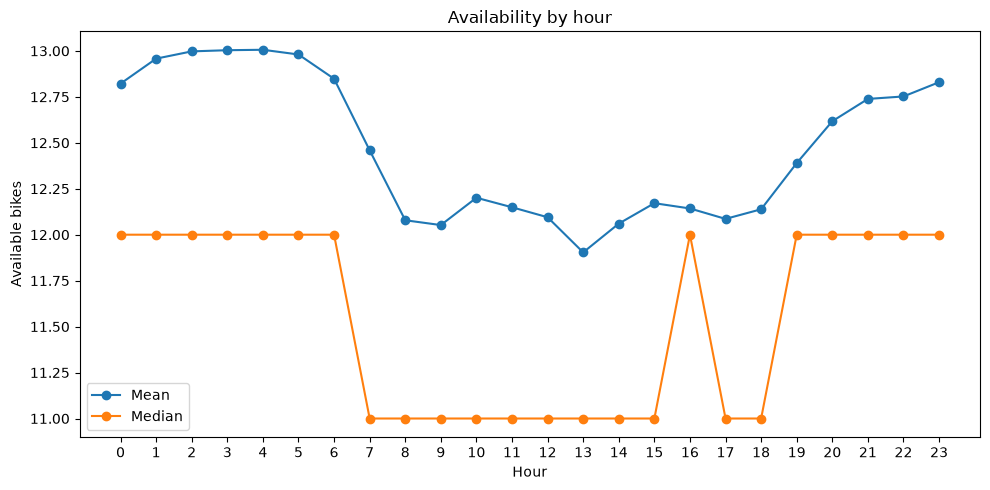

In [5]:
df["HOUR"] = df["TIME"].dt.hour
df["DAY_OF_WEEK"] = df["TIME"].dt.dayofweek
df["DAY_NAME"] = df["TIME"].dt.day_name()
df["IS_WEEKEND"] = df["DAY_OF_WEEK"].isin([5, 6])

hourly = df.groupby("HOUR")["AVAILABLE BIKES"].agg(["mean", "median"])

plt.figure(figsize=(10, 5))
plt.plot(hourly.index, hourly["mean"], marker="o", label="Mean")
plt.plot(hourly.index, hourly["median"], marker="o", label="Median")
plt.xticks(range(24))
plt.xlabel("Hour")
plt.ylabel("Available bikes")
plt.title("Availability by hour")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "availability_by_hour.png", dpi=150)
plt.show()

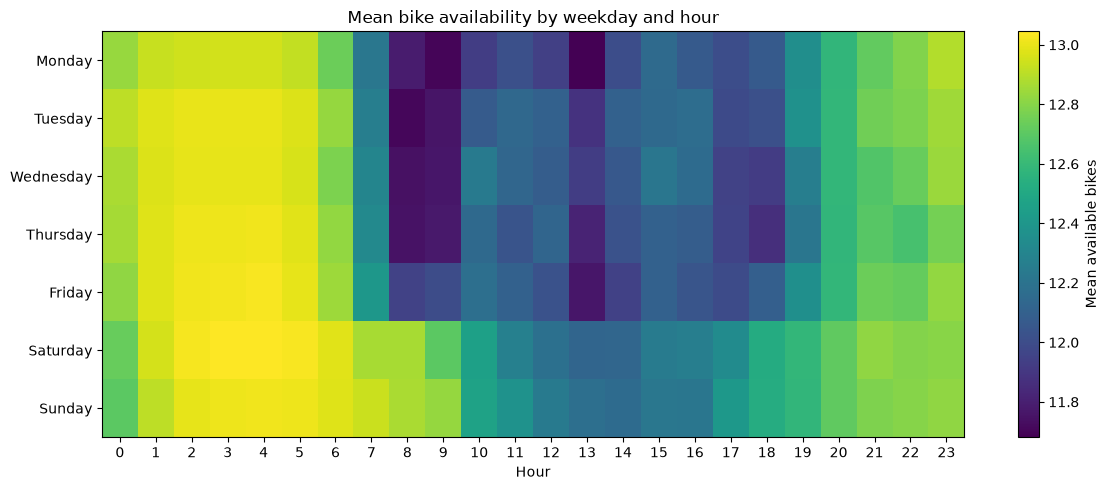

In [6]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]
heatmap_data = (
    df.pivot_table(
        index="DAY_NAME",
        columns="HOUR",
        values="AVAILABLE BIKES",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

plt.figure(figsize=(12, 5))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean available bikes")
plt.yticks(range(len(weekday_order)), weekday_order)
plt.xticks(range(24), range(24))
plt.xlabel("Hour")
plt.title("Mean bike availability by weekday and hour")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "weekday_hour_heatmap.png", dpi=150)
plt.show()

## Station-level variation

In [7]:
station_summary = (
    df.groupby("STATION ID")
      .agg(
          station_name=("NAME", "first") if "NAME" in df.columns else ("STATION ID", "first"),
          capacity=("BIKE STANDS", "median"),
          mean_available=("AVAILABLE BIKES", "mean"),
          std_available=("AVAILABLE BIKES", "std"),
          empty_rate=("AVAILABLE BIKES", lambda s: (s == 0).mean()),
      )
      .sort_values("std_available", ascending=False)
)
display(station_summary.head(15))

,station_name,capacity,mean_available,std_available,empty_rate
STATION ID,,,,,
114,WILTON TERRACE (PARK),40.0,13.528839,12.160166,0.147325
50,GEORGES LANE,40.0,18.592078,12.003116,0.040306
98,FREDERICK STREET SOUTH,40.0,16.343989,11.634762,0.100764
67,THE POINT,40.0,20.480195,11.506278,0.011119
38,TALBOT STREET,40.0,22.783878,10.597707,0.004864
69,GRAND CANAL DOCK,40.0,21.904795,10.292927,0.003475
92,HEUSTON BRIDGE (NORTH),40.0,25.539263,10.226147,0.002085
86,PARKGATE STREET,38.0,12.011814,10.150221,0.041696
5,CHARLEMONT PLACE,40.0,21.690757,10.067139,0.005559


## Short-term persistence

In [8]:
station_groups = df.groupby("STATION ID")["AVAILABLE BIKES"]
persistence = pd.DataFrame({
    "current": df["AVAILABLE BIKES"],
    "lag_1": station_groups.shift(1),
    "lag_2": station_groups.shift(2),
    "lag_4": station_groups.shift(4),
}).dropna()

display(persistence.corr())

print(
    "High correlation with recent observations supports adding lag features "
    "and comparing the model against a last-observation baseline."
)

,current,lag_1,lag_2,lag_4
current,1.000000,0.971236,0.939794,0.876197
lag_1,0.971236,1.000000,0.971239,0.907874
lag_2,0.939794,0.971239,1.000000,0.939813
lag_4,0.876197,0.907874,0.939813,1.000000


High correlation with recent observations supports adding lag features and comparing the model against a last-observation baseline.
